In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
from sklearn.metrics import confusion_matrix

# Load data

In [33]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 6.77 GB, difference +4.57 GB
CPU times: user 471 ms, sys: 2 s, total: 2.47 s
Wall time: 5.5 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/scanpy/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Confusion matrix

In [34]:
df = adata.obs[['assigned_condition', 'dataset', 'S_score', 'G2M_score', 'phase']].copy()

df = df[df['dataset'] == 'Control']
print(f'Total cells: {df.shape[0]}')

# drop rows with missing labels
df = df.dropna(subset=['assigned_condition', 'phase'])

print(f'After dropping missing labels: {df.shape[0]}')
df.head()

Total cells: 6902
After dropping missing labels: 6858


,assigned_condition,dataset,S_score,G2M_score,phase
AAACCAAAGGGTAGCA_control,G2M,Control,0.251102,2.275294,G2M
AAACCAAAGTAAGGGT_control,G1,Control,-0.891634,-1.126471,G1
AAACCATTCAGGTAGG_control,G1,Control,0.049592,2.255882,G2M
AAACCATTCCAGCCCT_control,S,Control,-1.128118,-2.258627,G1
AAACCATTCGTGACCG_control,G1,Control,-1.010752,-1.492157,G1


(3, 3)


,G1,S,G2M
G1,2948,292,1321
S,392,82,622
G2M,159,19,1023


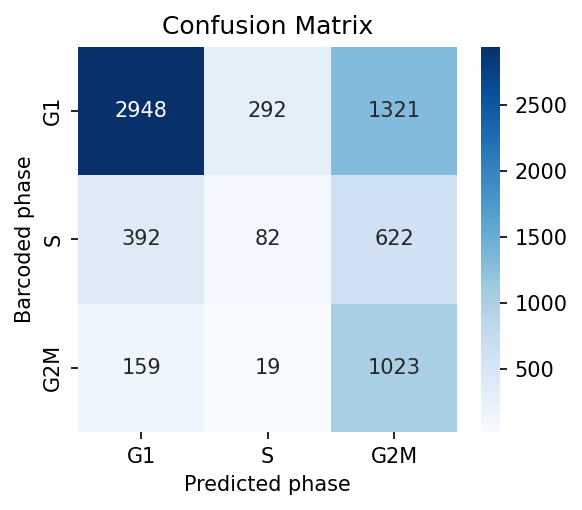

In [35]:
labels = ['G1', 'S', 'G2M'] #sorted(set(df["phase"]) | set(df["assigned_condition"]))

# Compute confusion matrix
cm = confusion_matrix(
    df["assigned_condition"], # y_true
    df["phase"], # y_pred
    labels=labels
)

# Convert to DataFrame for nicer plotting
cdf = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print(cdf.shape)
display(cdf)


plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cdf,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.ylabel("Barcoded phase")
plt.xlabel("Predicted phase")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

,G1,S,G2M
G1,0.646349,0.064021,0.289629
S,0.357664,0.074818,0.567518
G2M,0.132390,0.015820,0.851790


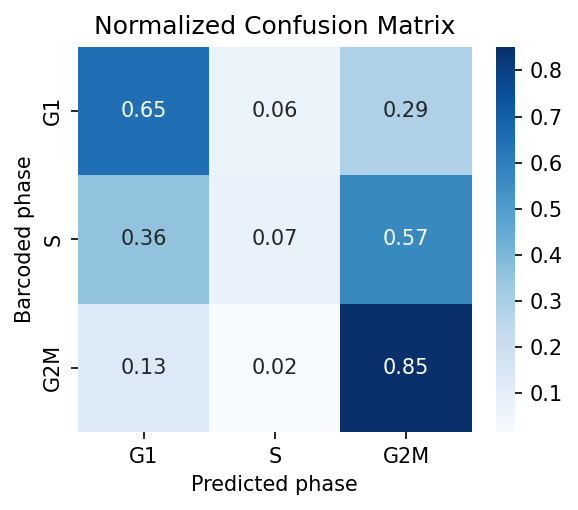

In [36]:
cm_norm = confusion_matrix(
    df["assigned_condition"],
    df["phase"],
    labels=labels,
    normalize="true"
)

cndf = pd.DataFrame(
    cm_norm,
    index=labels,
    columns=labels
)

display(cndf)

plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cndf,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True
)

plt.ylabel("Barcoded phase")
plt.xlabel("Predicted phase")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [37]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
regev_genes = [g for g in regev_genes if g in adata.var_names]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

CPU times: user 399 μs, sys: 0 ns, total: 399 μs
Wall time: 1.09 ms


In [38]:
# score cell cycle (no scaling)
adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

,phase
AAACCAAAGCAACTGC_hybrid,G2M
AAACCAAAGTAGGGCA_hybrid,S
AAACCAAAGTCTAGGC_hybrid,G1
AAACCATTCACGTAAT_hybrid,G2M
AAACCATTCAGGCAGA_hybrid,G2M


In [39]:
df = adata.obs[['assigned_condition', 'dataset', 'S_score', 'G2M_score', 'phase']].copy()

df = df[df['dataset'] == 'Control']
print(f'Total cells: {df.shape[0]}')

# drop rows with missing labels
df = df.dropna(subset=['assigned_condition', 'phase'])

print(f'After dropping missing labels: {df.shape[0]}')
df.head()

Total cells: 6902
After dropping missing labels: 6858


,assigned_condition,dataset,S_score,G2M_score,phase
AAACCAAAGGGTAGCA_control,G2M,Control,0.341547,0.755781,G2M
AAACCAAAGTAAGGGT_control,G1,Control,-0.811242,-2.118885,G1
AAACCATTCAGGTAGG_control,G1,Control,0.007893,0.600677,G2M
AAACCATTCCAGCCCT_control,S,Control,-0.971924,-3.988340,G1
AAACCATTCGTGACCG_control,G1,Control,-0.904326,-2.353397,G1


(3, 3)


,G1,S,G2M
G1,3251,504,806
S,604,266,226
G2M,385,87,729


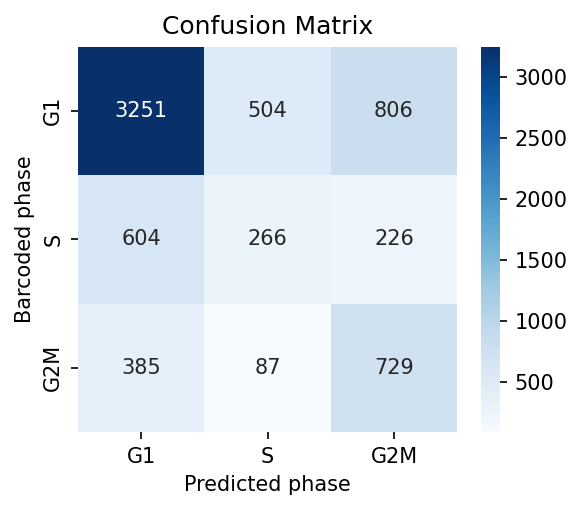

In [40]:
labels = ['G1', 'S', 'G2M'] #sorted(set(df["phase"]) | set(df["assigned_condition"]))

# Compute confusion matrix
cm = confusion_matrix(
    df["assigned_condition"], # y_true
    df["phase"], # y_pred
    labels=labels
)

# Convert to DataFrame for nicer plotting
cdf = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print(cdf.shape)
display(cdf)


plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cdf,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.ylabel("Barcoded phase")
plt.xlabel("Predicted phase")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

,G1,S,G2M
G1,0.712782,0.110502,0.176716
S,0.551095,0.242701,0.206204
G2M,0.320566,0.072440,0.606994


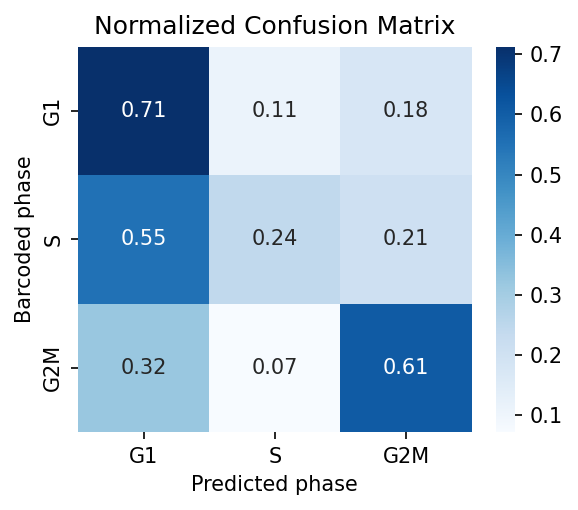

In [41]:
cm_norm = confusion_matrix(
    df["assigned_condition"],
    df["phase"],
    labels=labels,
    normalize="true"
)

cndf = pd.DataFrame(
    cm_norm,
    index=labels,
    columns=labels
)

display(cndf)

plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cndf,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True
)

plt.ylabel("Barcoded phase")
plt.xlabel("Predicted phase")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()